# Introduksjon til pandas og matplotlib

Denne notebooken er en innføring i **pandas** (databehandling) og **matplotlib** (visualisering) i Python. Målet er å gi deg et grunnlag for å bygge egne trading-algoritmer, tilsvarende den enkle modellen i `intro.ipynb` (kjøp når prisen er under 30-dagers glidende gjennomsnitt, selg ellers).

Vi bruker historiske aksjekurser for Apple (`Apple_Stock_Price_History.csv`) som eksempeldata gjennom hele notebooken, så du ser nøyaktig hvordan dataen ser ut i praksis.

**Innhold:**
1. Importere biblioteker
2. Laste inn data
3. Utforske en DataFrame
4. Velge og filtrere data
5. Rydde opp i dataen
6. Enkle beregninger
7. Rullende gjennomsnitt (moving average)
8. Plotting med matplotlib
9. Bygge et enkelt signal
10. Oppsummering og øvelser

## 1. Importere biblioteker

To forkortelser du vil se overalt i Python-verdenen: `pd` for pandas og `plt` for matplotlib sin `pyplot`-modul.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Laste inn data

`pd.read_csv()` leser en CSV-fil og gir deg en **DataFrame** — en tabell med rader og kolonner, litt som et Excel-ark. Her er hver rad én handelsdag, og kolonnene er pris, volum osv.

In [5]:
file_path = "data/apple_data.csv"
df = pd.read_csv(file_path)
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,09/01/2026,325.13,316.98,327.22,314.76,50.84M,2.61%
1,08/31/2026,316.85,319.60,321.23,312.80,41.24M,-0.89%
2,08/28/2026,319.70,316.85,322.37,315.45,38.65M,1.63%
3,08/27/2026,314.58,310.55,315.40,309.40,32.42M,0.36%
4,08/26/2026,313.45,310.30,315.43,308.80,34.02M,1.15%


`.head()` viser de 5 første radene som standard (du kan skrive `df.head(10)` for flere). `.tail()` gjør det samme fra slutten av tabellen.

In [6]:
df.tail()

,Date,Price,Open,High,Low,Vol.,Change %
162,01/08/2026,259.04,257.02,259.29,255.70,50.42M,-0.50%
163,01/07/2026,260.33,263.20,263.68,259.81,48.31M,-0.77%
164,01/06/2026,262.36,267.00,267.55,262.12,52.35M,-1.83%
165,01/05/2026,267.26,270.64,271.51,266.14,45.65M,-1.38%
166,01/02/2026,271.01,272.26,277.84,269.00,37.84M,-0.31%


## 3. Utforske en DataFrame

Før du gjør noe med dataen bør du bli kjent med den. Noen nyttige metoder/attributter:

- `.shape` — antall rader og kolonner
- `.columns` — kolonnenavn
- `.dtypes` — datatype per kolonne
- `.describe()` — enkel statistikk for numeriske kolonner

In [7]:
print("Antall rader og kolonner:", df.shape)
print("Kolonner:", list(df.columns))

Antall rader og kolonner: (167, 7)
Kolonner: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']


In [8]:
df.dtypes

Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.         object
Change %     object
dtype: object

Legg merke til at `Price`, `Open`, `High` og `Low` allerede er lest inn som `float64` (tall), mens `Date`, `Vol.` og `Change %` er lest inn som tekst (`str`/`object`). Det er fordi de inneholder ting pandas ikke automatisk tolker som tall: et datoformat, bokstaven "M" for millioner, og et prosenttegn. Det må vi rydde opp i snart.

In [9]:
df.describe()

,Price,Open,High,Low
count,167.000000,167.000000,167.000000,167.000000
mean,284.665269,284.275210,287.669042,281.344790
std,25.764244,25.264423,25.853062,25.231436
min,246.630000,247.320000,249.200000,243.420000
25%,260.485000,259.610000,262.175000,257.530000
50%,278.120000,278.130000,284.570000,274.860000
75%,308.725000,307.665000,311.600000,305.345000
max,340.080000,340.030000,344.570000,337.350000


`.describe()` gir deg antall verdier, gjennomsnitt, standardavvik, min/max og kvartiler — kun for de numeriske kolonnene. Rask måte å luke ut rariteter i dataen på.

## 4. Velge og filtrere data

- `df["kolonne"]` → én kolonne (en `Series`)
- `df[["a", "b"]]` → flere kolonner (en `DataFrame`)
- `.iloc[]` → posisjonsbasert utvalg
- `.loc[]` → labelbasert utvalg
- boolsk indeksering → filtrere rader på en betingelse

In [10]:
df["Price"].head()

0    325.13
1    316.85
2    319.70
3    314.58
4    313.45
Name: Price, dtype: float64

In [11]:
df[["Date", "Price"]].head()

,Date,Price
0,09/01/2026,325.13
1,08/31/2026,316.85
2,08/28/2026,319.70
3,08/27/2026,314.58
4,08/26/2026,313.45


`.iloc` bruker posisjon (som indeks i en liste), `.loc` bruker rad-/kolonnenavn (label). Siden indeksen her fortsatt er 0, 1, 2, … blir de ofte like i praksis, men det er lurt å skille dem tidlig — de oppfører seg ulikt så snart indeksen ikke lenger er enkle tall.

In [12]:
df.iloc[0]   # første rad, posisjonsbasert

Date        09/01/2026
Price           325.13
Open            316.98
High            327.22
Low             314.76
Vol.            50.84M
Change %         2.61%
Name: 0, dtype: object

In [13]:
df.loc[0:4, ["Date", "Price"]]   # rad 0 til og med 4, kun to kolonner

,Date,Price
0,09/01/2026,325.13
1,08/31/2026,316.85
2,08/28/2026,319.70
3,08/27/2026,314.58
4,08/26/2026,313.45


Boolsk indeksering (filtrering) er en av de mest brukte teknikkene når du bygger trading-signaler: du lager en betingelse som er `True`/`False` for hver rad, og bruker den til å plukke ut radene som stemmer.

In [14]:
dyre_dager = df[df["Price"] > 300]
print(f"Antall dager med pris over 300: {len(dyre_dager)}")
dyre_dager.head()

Antall dager med pris over 300: 57


,Date,Price,Open,High,Low,Vol.,Change %
0,09/01/2026,325.13,316.98,327.22,314.76,50.84M,2.61%
1,08/31/2026,316.85,319.60,321.23,312.80,41.24M,-0.89%
2,08/28/2026,319.70,316.85,322.37,315.45,38.65M,1.63%
3,08/27/2026,314.58,310.55,315.40,309.40,32.42M,0.36%
4,08/26/2026,313.45,310.30,315.43,308.80,34.02M,1.15%


## 5. Rydde opp i dataen

`Date`-kolonnen er foreløpig tekst, ikke en ordentlig dato. Det gjør det vanskelig å sortere kronologisk og å plotte riktig langs x-aksen. `pd.to_datetime()` konverterer tekst til ordentlige datoobjekter.

In [15]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df.dtypes

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.                object
Change %            object
dtype: object

Legg merke til at dataen ligger sortert med **nyeste dato først**. For tidsseriearbeid (og for plotting) vil vi som regel ha kronologisk rekkefølge, altså eldste først.

In [16]:
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2026-01-02,271.01,272.26,277.84,269.00,37.84M,-0.31%
1,2026-01-05,267.26,270.64,271.51,266.14,45.65M,-1.38%
2,2026-01-06,262.36,267.00,267.55,262.12,52.35M,-1.83%
3,2026-01-07,260.33,263.20,263.68,259.81,48.31M,-0.77%
4,2026-01-08,259.04,257.02,259.29,255.70,50.42M,-0.50%


`Vol.` og `Change %` er lest inn som tekst fordi de inneholder bokstaven "M" og et prosenttegn. Med `.str`-metoder kan vi rense tekststrenger og gjøre dem om til tall — samme mønster som over med boolske betingelser: gjør noe med hele kolonnen på én gang.

In [17]:
df["Change %"] = df["Change %"].str.rstrip("%").astype(float)
df["Vol."] = df["Vol."].str.rstrip("M").astype(float) * 1_000_000

df[["Date", "Vol.", "Change %"]].head()

,Date,Vol.,Change %
0,2026-01-02,37840000.0,-0.31
1,2026-01-05,45650000.0,-1.38
2,2026-01-06,52350000.0,-1.83
3,2026-01-07,48310000.0,-0.77
4,2026-01-08,50420000.0,-0.50


## 6. Enkle beregninger

Kolonner i en DataFrame kan regnes med akkurat som med tall — operasjonene skjer på hele kolonnen samtidig ("vektorisert"), helt uten `for`-løkker.

In [18]:
df["Daglig_endring"] = df["Price"].diff()
df["Daglig_avkastning_%"] = df["Price"].pct_change() * 100

df[["Date", "Price", "Daglig_endring", "Daglig_avkastning_%"]].head()

,Date,Price,Daglig_endring,Daglig_avkastning_%
0,2026-01-02,271.01,NaN,NaN
1,2026-01-05,267.26,-3.75,-1.383713
2,2026-01-06,262.36,-4.90,-1.833421
3,2026-01-07,260.33,-2.03,-0.773746
4,2026-01-08,259.04,-1.29,-0.495525


`.diff()` gir differansen mot forrige rad (i dag minus i går), `.pct_change()` gir prosentvis endring mot forrige rad. Første rad blir `NaN` (tom) siden det ikke finnes noen "i går" å sammenligne med.

In [19]:
print(f"Gjennomsnittlig daglig avkastning: {df['Daglig_avkastning_%'].mean():.3f}%")
print(f"Standardavvik (volatilitet):        {df['Daglig_avkastning_%'].std():.3f}%")
print(f"Beste dag:                          {df['Daglig_avkastning_%'].max():.2f}%")
print(f"Verste dag:                         {df['Daglig_avkastning_%'].min():.2f}%")

Gjennomsnittlig daglig avkastning: 0.125%
Standardavvik (volatilitet):        1.721%
Beste dag:                          4.84%
Verste dag:                         -7.35%


## 7. Rullende gjennomsnitt (moving average)

Et glidende/rullende gjennomsnitt tar gjennomsnittet av de siste `n` dagene, og "glir" fremover én dag av gangen. Dette er selve grunnsteinen i strategien i `intro.ipynb`: `.rolling(window=n).mean()`.

In [20]:
df["MA_10"] = df["Price"].rolling(window=10).mean()
df["MA_30"] = df["Price"].rolling(window=30).mean()

df[["Date", "Price", "MA_10", "MA_30"]].tail(10)

,Date,Price,MA_10,MA_30
157,2026-08-19,316.83,308.480,318.641000
158,2026-08-20,311.30,308.369,318.477000
159,2026-08-21,309.35,307.971,318.278000
160,2026-08-24,310.34,308.179,318.045667
161,2026-08-25,309.90,308.678,317.880333
162,2026-08-26,313.45,309.798,317.412000
163,2026-08-27,314.58,310.730,316.789333
164,2026-08-28,319.70,312.107,316.321333
165,2026-08-31,316.85,313.233,315.996667
166,2026-09-01,325.13,314.743,315.909667


Merk at `MA_10` og `MA_30` er `NaN` (tomme) helt i starten av datasettet — det finnes rett og slett ikke nok tidligere dager å regne gjennomsnitt av ennå.

## 8. Plotting med matplotlib

Grunnoppskriften: `plt.plot(x, y)`, deretter `plt.title()`, `plt.xlabel()`, `plt.ylabel()`, ev. `plt.legend()`, og til slutt `plt.show()`.

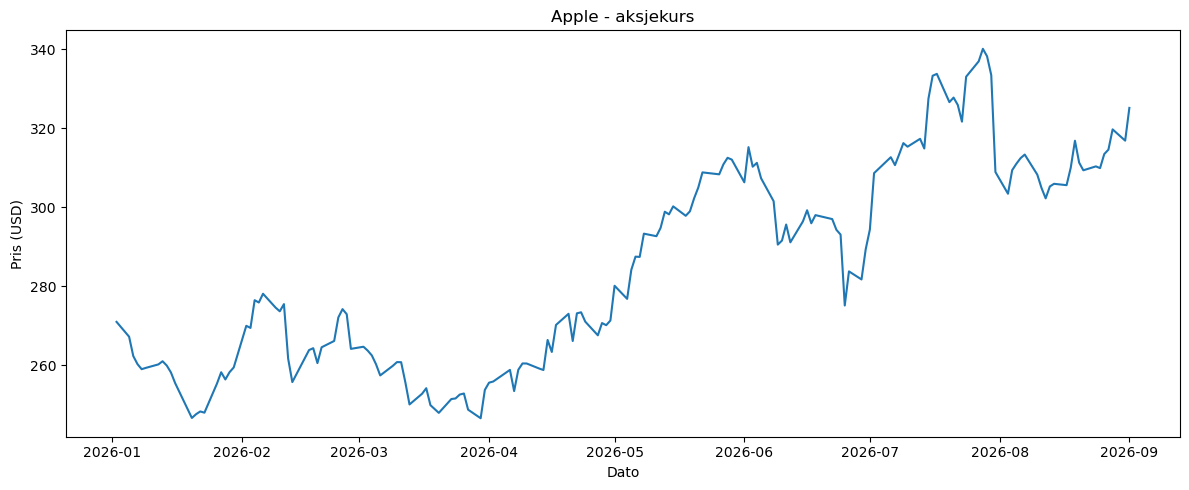

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Price"])
plt.title("Apple - aksjekurs")
plt.xlabel("Dato")
plt.ylabel("Pris (USD)")
plt.tight_layout()
plt.show()

For å sammenligne flere linjer i samme figur, kall bare `plt.plot()` flere ganger før `plt.show()`. Legg til `label=` på hver linje og `plt.legend()` for å få en forklaring på figuren.

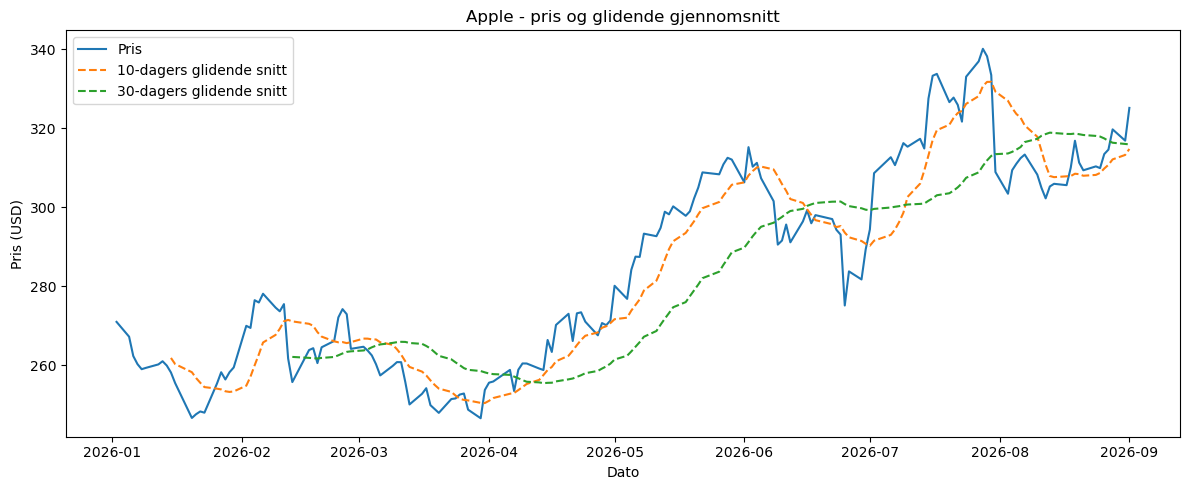

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Price"], label="Pris", linewidth=1.5)
plt.plot(df["Date"], df["MA_10"], label="10-dagers glidende snitt", linewidth=1.5, linestyle="--")
plt.plot(df["Date"], df["MA_30"], label="30-dagers glidende snitt", linewidth=1.5, linestyle="--")
plt.title("Apple - pris og glidende gjennomsnitt")
plt.xlabel("Dato")
plt.ylabel("Pris (USD)")
plt.legend()
plt.tight_layout()
plt.show()

matplotlib kan mye mer enn linjediagram. Et histogram er nyttig for å se hvordan daglig avkastning fordeler seg — er de fleste dagene rolige, eller svinger det mye?

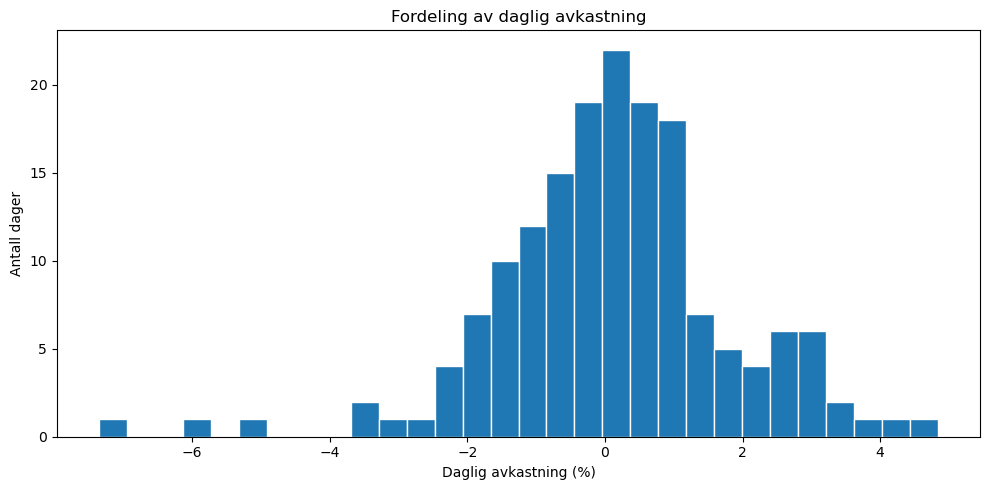

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(df["Daglig_avkastning_%"].dropna(), bins=30, edgecolor="white")
plt.title("Fordeling av daglig avkastning")
plt.xlabel("Daglig avkastning (%)")
plt.ylabel("Antall dager")
plt.tight_layout()
plt.show()

## 9. Bygge et enkelt signal

I `intro.ipynb` lages et kjøpssignal med én linje kode: en boolsk betingelse blir gjort om til 0/1 med `.astype(int)`. Her er samme teknikk, brukt på 10-dagers snittet i stedet for 30-dagers:

In [24]:
df["Over_MA10"] = (df["Price"] > df["MA_10"]).astype(int)
df[["Date", "Price", "MA_10", "Over_MA10"]].tail(10)

,Date,Price,MA_10,Over_MA10
157,2026-08-19,316.83,308.480,1
158,2026-08-20,311.30,308.369,1
159,2026-08-21,309.35,307.971,1
160,2026-08-24,310.34,308.179,1
161,2026-08-25,309.90,308.678,1
162,2026-08-26,313.45,309.798,1
163,2026-08-27,314.58,310.730,1
164,2026-08-28,319.70,312.107,1
165,2026-08-31,316.85,313.233,1
166,2026-09-01,325.13,314.743,1


Du kan visualisere hvor betingelsen er sann ved å filtrere ut de radene og plotte dem oppå prislinjen med `plt.scatter()`.

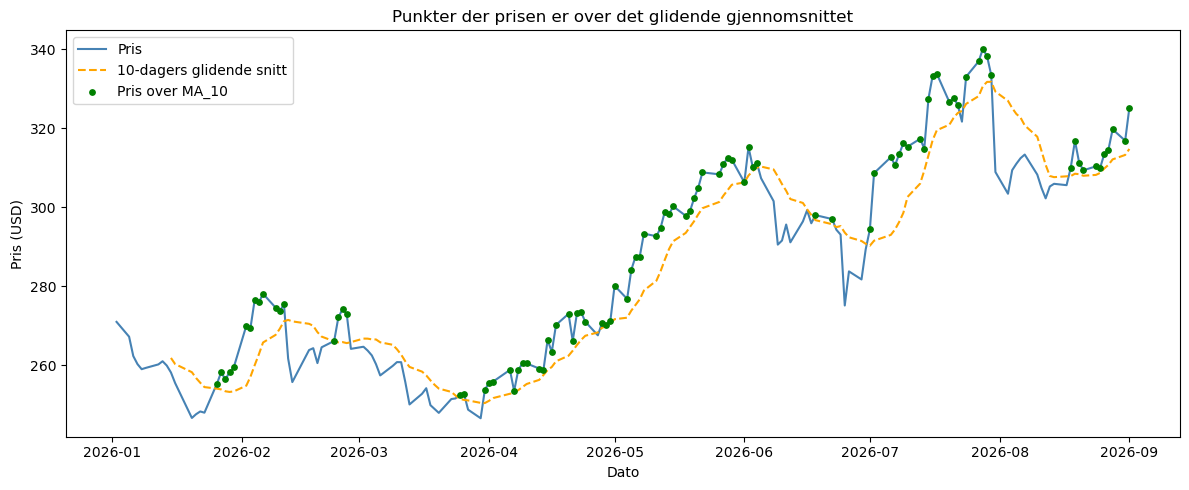

In [25]:
over = df[df["Over_MA10"] == 1]

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Price"], label="Pris", linewidth=1.5, color="steelblue")
plt.plot(df["Date"], df["MA_10"], label="10-dagers glidende snitt", linewidth=1.5, linestyle="--", color="orange")
plt.scatter(over["Date"], over["Price"], label="Pris over MA_10", color="green", s=15, zorder=3)
plt.title("Punkter der prisen er over det glidende gjennomsnittet")
plt.xlabel("Dato")
plt.ylabel("Pris (USD)")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Oppsummering og øvelser

Du har nå sett de byggeklossene som `intro.ipynb` setter sammen til en enkel trading-strategi:

1. **Laste inn og rydde data** (`pd.read_csv`, `pd.to_datetime`, `.str`-metoder)
2. **Utforske og velge data** (`.head()`, `.describe()`, `.loc`/`.iloc`, boolsk filtrering)
3. **Regne ut nye kolonner** (`.diff()`, `.pct_change()`, `.rolling().mean()`)
4. **Lage et signal** — en boolsk betingelse gjort om til 0/1
5. **Plotte resultatet** med `plt.plot()`, `plt.scatter()`, `plt.hist()`

I `intro.ipynb` går man videre fra signalet (`Buy_signal`) til en **backtest**: en løkke som flytter en tenkt sum penger mellom kontanter og aksjer basert på signalet, dag for dag, og til slutt plotter porteføljeverdien opp mot aksjekursen.

### Prøv selv

- Endre vindusstørrelsen i det glidende gjennomsnittet (f.eks. 5 og 50 dager i stedet for 10 og 30) og se hvordan grafen endrer seg.
- Lag et nytt signal som slår til når prisen er under `Low`-verdien de siste 10 dagene i stedet for under `MA_10`.
- Regn ut kumulativ avkastning for perioden (hint: `(1 + df["Daglig_avkastning_%"] / 100).cumprod()`).
- Gå til investing.com og last ned data for en ny aksje. Forsøk å endre datafilen, og kjør analysen på nytt.
- Åpne `intro.ipynb` og se om du kjenner igjen mønstrene herfra i backtest-løkken og sluttplottet.